# 1. Data Understanding

This section focuses on exploring the structure, quality, and key characteristics of the dataset before analysis.

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Description

The data consists of two tables:

- **patient_profiles**: static patient information  
- **treatment_journey**: treatment cycles and outcomes  

These datasets will be merged for analysis.

In [4]:
patient_df = pd.read_csv('../datasets/patient_profiles.csv', delimiter=',')
patient_df.head()

,Patient_ID,Age_at_Diagnosis,Molecular_Subtype,BRCA_Mutation,Tumor_Grade,Initial_Tumor_Size_mm
0,BC-00001,60,Triple-Negative,0,1,15.11
1,BC-00002,53,HER2-Enriched,0,1,11.67
2,BC-00003,62,Luminal A,0,1,44.78
3,BC-00004,73,Luminal A,0,1,11.24
4,BC-00005,52,Luminal A,1,1,12.90


In [5]:
treatment_df = pd.read_csv('../datasets/treatment_journey.csv', delimiter=',')
treatment_df.head()

,Patient_ID,Treatment_Round,Regimen,Tumor_Shrinkage_Pct,CA15_3_Level,Side_Effect_Severity,Response_Status
0,BC-00001,1,AC-T (Adriamycin/Cytoxan/Taxol),37.36,28.13,4,Partial
1,BC-00001,2,Docetaxel + Carboplatin,22.61,21.77,7,Partial
2,BC-00002,1,AC-T (Adriamycin/Cytoxan/Taxol),85.66,10.99,6,Complete
3,BC-00003,1,AC-T (Adriamycin/Cytoxan/Taxol),30.25,61.34,9,Partial
4,BC-00003,2,Exemestane,32.34,41.51,3,Partial


In [30]:
print("Patient dataset shape:", patient_df.shape)
print("Treatment dataset shape:", treatment_df.shape)

patient_df.head()

Patient dataset shape: (2500, 6)
Treatment dataset shape: (4981, 7)


,Patient_ID,Age_at_Diagnosis,Molecular_Subtype,BRCA_Mutation,Tumor_Grade,Initial_Tumor_Size_mm
0,BC-00001,60,Triple-Negative,0,1,15.11
1,BC-00002,53,HER2-Enriched,0,1,11.67
2,BC-00003,62,Luminal A,0,1,44.78
3,BC-00004,73,Luminal A,0,1,11.24
4,BC-00005,52,Luminal A,1,1,12.90


### Observations

- No missing values detected  
- Data types are consistent  
- Dataset includes both numerical and categorical features  

Check uniqueness of Patient_ID

In [31]:
print("Patient_ID uniqueness (patient_df):")
print(patient_df['Patient_ID'].nunique(), "/", len(patient_df))

print("\nPatient_ID uniqueness (treatment_df):")
print(treatment_df['Patient_ID'].nunique(), "/", len(treatment_df))

Patient_ID uniqueness (patient_df):
2500 / 2500

Patient_ID uniqueness (treatment_df):
2500 / 4981


Check duplicates

In [32]:
print("Duplicates in patient_df:", patient_df.duplicated().sum())
print("Duplicates in treatment_df:", treatment_df.duplicated().sum())

Duplicates in patient_df: 0
Duplicates in treatment_df: 0


In [6]:
patient_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             2500 non-null   object 
 1   Age_at_Diagnosis       2500 non-null   int64  
 2   Molecular_Subtype      2500 non-null   object 
 3   BRCA_Mutation          2500 non-null   int64  
 4   Tumor_Grade            2500 non-null   int64  
 5   Initial_Tumor_Size_mm  2500 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 117.3+ KB


In [7]:
treatment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Patient_ID            4981 non-null   object 
 1   Treatment_Round       4981 non-null   int64  
 2   Regimen               4981 non-null   object 
 3   Tumor_Shrinkage_Pct   4981 non-null   float64
 4   CA15_3_Level          4981 non-null   float64
 5   Side_Effect_Severity  4981 non-null   int64  
 6   Response_Status       4981 non-null   object 
dtypes: float64(2), int64(2), object(3)
memory usage: 272.5+ KB


### Data Merge

The datasets are merged using a **left join** on `Patient_ID` to preserve all treatment records, even if some patient profile data might be missing.

This ensures that no treatment observations are lost.

In [8]:
analysis_df = treatment_df.merge(patient_df, on='Patient_ID', how='left')

#### Initial overview

In [9]:
analysis_df.head(10)

,Patient_ID,Treatment_Round,Regimen,Tumor_Shrinkage_Pct,CA15_3_Level,Side_Effect_Severity,Response_Status,Age_at_Diagnosis,Molecular_Subtype,BRCA_Mutation,Tumor_Grade,Initial_Tumor_Size_mm
0,BC-00001,1,AC-T (Adriamycin/Cytoxan/Taxol),37.36,28.13,4,Partial,60,Triple-Negative,0,1,15.11
1,BC-00001,2,Docetaxel + Carboplatin,22.61,21.77,7,Partial,60,Triple-Negative,0,1,15.11
2,BC-00002,1,AC-T (Adriamycin/Cytoxan/Taxol),85.66,10.99,6,Complete,53,HER2-Enriched,0,1,11.67
3,BC-00003,1,AC-T (Adriamycin/Cytoxan/Taxol),30.25,61.34,9,Partial,62,Luminal A,0,1,44.78
4,BC-00003,2,Exemestane,32.34,41.51,3,Partial,62,Luminal A,0,1,44.78
5,BC-00004,1,AC-T (Adriamycin/Cytoxan/Taxol),43.76,25.55,8,Partial,73,Luminal A,0,1,11.24
6,BC-00004,2,Exemestane,16.06,21.45,5,Refractory,73,Luminal A,0,1,11.24
7,BC-00005,1,AC-T (Adriamycin/Cytoxan/Taxol),30.75,56.87,8,Partial,52,Luminal A,1,1,12.90
8,BC-00005,2,Exemestane,62.55,21.30,7,Partial,52,Luminal A,1,1,12.90
9,BC-00006,1,AC-T (Adriamycin/Cytoxan/Taxol),51.34,21.52,6,Partial,52,Luminal A,0,3,23.51


In [10]:
analysis_df.tail(10)

,Patient_ID,Treatment_Round,Regimen,Tumor_Shrinkage_Pct,CA15_3_Level,Side_Effect_Severity,Response_Status,Age_at_Diagnosis,Molecular_Subtype,BRCA_Mutation,Tumor_Grade,Initial_Tumor_Size_mm
4971,BC-02496,1,AC-T (Adriamycin/Cytoxan/Taxol),46.37,56.02,5,Partial,64,Luminal A,0,1,12.66
4972,BC-02496,2,Exemestane,22.88,43.20,4,Partial,64,Luminal A,0,1,12.66
4973,BC-02497,1,AC-T (Adriamycin/Cytoxan/Taxol),27.51,53.80,6,Stable/Progressive,51,Triple-Negative,0,1,18.94
4974,BC-02497,2,Docetaxel + Carboplatin,34.91,35.02,4,Partial,51,Triple-Negative,0,1,18.94
4975,BC-02498,1,AC-T (Adriamycin/Cytoxan/Taxol),51.76,18.55,9,Partial,51,Luminal A,0,3,40.31
4976,BC-02498,2,Exemestane,16.76,15.44,6,Refractory,51,Luminal A,0,3,40.31
4977,BC-02499,1,AC-T (Adriamycin/Cytoxan/Taxol),64.52,26.48,5,Partial,64,Luminal B,0,3,5.69
4978,BC-02499,2,Exemestane,40.43,15.77,2,Partial,64,Luminal B,0,3,5.69
4979,BC-02500,1,AC-T (Adriamycin/Cytoxan/Taxol),35.06,72.60,7,Partial,59,Luminal A,0,2,17.71
4980,BC-02500,2,Exemestane,15.33,61.47,4,Refractory,59,Luminal A,0,2,17.71


Merged dataset has 4981 rows and total 12 columns

Feature groups:

1.	Patient characteristics
Age_at_Diagnosis, BRCA_Mutation

2.	Tumor features:
Initial_Tumor_Size_mm, Tumor_Grade, Molecular_Subtype

3.	Treatment information:
Regimen, Treatment_Round

4.	Clinical indicators:
CA15_3_Level, Tumor_Shrinkage_Pct

In [28]:
analysis_df.shape

(4981, 12)

In [11]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             4981 non-null   object 
 1   Treatment_Round        4981 non-null   int64  
 2   Regimen                4981 non-null   object 
 3   Tumor_Shrinkage_Pct    4981 non-null   float64
 4   CA15_3_Level           4981 non-null   float64
 5   Side_Effect_Severity   4981 non-null   int64  
 6   Response_Status        4981 non-null   object 
 7   Age_at_Diagnosis       4981 non-null   int64  
 8   Molecular_Subtype      4981 non-null   object 
 9   BRCA_Mutation          4981 non-null   int64  
 10  Tumor_Grade            4981 non-null   int64  
 11  Initial_Tumor_Size_mm  4981 non-null   float64
dtypes: float64(3), int64(5), object(4)
memory usage: 467.1+ KB


No missing values were detected across all features, indicating a clean dataset.

In [12]:
def missingness_report(df):
    report = pd.DataFrame({
        'column': df.columns,
        'dtype': df.dtypes,
        'missing_count': df.isnull().sum(),
        'missing_percent': (df.isnull().sum() / len(df)) * 100
    })
    
    report = report.sort_values(by='missing_percent', ascending=False)
    return report

report = missingness_report(analysis_df)
print(report)

                                      column    dtype  missing_count  \
Patient_ID                        Patient_ID   object              0   
Treatment_Round              Treatment_Round    int64              0   
Regimen                              Regimen   object              0   
Tumor_Shrinkage_Pct      Tumor_Shrinkage_Pct  float64              0   
CA15_3_Level                    CA15_3_Level  float64              0   
Side_Effect_Severity    Side_Effect_Severity    int64              0   
Response_Status              Response_Status   object              0   
Age_at_Diagnosis            Age_at_Diagnosis    int64              0   
Molecular_Subtype          Molecular_Subtype   object              0   
BRCA_Mutation                  BRCA_Mutation    int64              0   
Tumor_Grade                      Tumor_Grade    int64              0   
Initial_Tumor_Size_mm  Initial_Tumor_Size_mm  float64              0   

                       missing_percent  
Patient_ID            

### Data Quality Checks

- Tumor shrinkage should be within 0–100%  
- Side effect severity should be between 1–10  
- CA15-3 levels must be non-negative  

Invalid values were identified and filtered out.

In [13]:
treatment_counts = analysis_df.groupby('Patient_ID').size()

one_treatment_round = treatment_counts[treatment_counts != 2]

report = one_treatment_round.reset_index()
report.columns = ['Patient_ID', 'treatment_count']

print(report)

   Patient_ID  treatment_count
0    BC-00002                1
1    BC-00012                1
2    BC-00014                1
3    BC-00199                1
4    BC-00317                1
5    BC-00361                1
6    BC-00472                1
7    BC-00563                1
8    BC-00598                1
9    BC-00606                1
10   BC-00858                1
11   BC-01381                1
12   BC-01446                1
13   BC-01479                1
14   BC-01632                1
15   BC-02019                1
16   BC-02101                1
17   BC-02296                1
18   BC-02393                1


In [14]:
extra_treatment_rounds = treatment_counts[treatment_counts > 2]

extra_treatment_rounds

Series([], dtype: int64)

In [26]:
analysis_df.duplicated().sum()

np.int64(0)

In [27]:
for col in ['Regimen', 'Molecular_Subtype', 'Response_Status']:
    print(col, analysis_df[col].nunique())
    print(analysis_df[col].value_counts(), "\n")

Regimen 3
Regimen
AC-T (Adriamycin/Cytoxan/Taxol)    2500
Exemestane                         1657
Docetaxel + Carboplatin             824
Name: count, dtype: int64 

Molecular_Subtype 4
Molecular_Subtype
Luminal A          2320
Luminal B           994
Triple-Negative     977
HER2-Enriched       690
Name: count, dtype: int64 

Response_Status 4
Response_Status
Partial               4198
Refractory             490
Stable/Progressive     274
Complete                19
Name: count, dtype: int64 



In [15]:
analysis_df.describe()

,Treatment_Round,Tumor_Shrinkage_Pct,CA15_3_Level,Side_Effect_Severity,Age_at_Diagnosis,BRCA_Mutation,Tumor_Grade,Initial_Tumor_Size_mm
count,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000
mean,1.498093,37.701899,36.443333,5.555912,54.915077,0.119855,2.096165,29.571666
std,0.500047,14.696995,16.675000,1.985170,11.793718,0.324825,0.688829,20.635767
min,1.000000,0.000000,-1.490000,2.000000,16.000000,0.000000,1.000000,1.020000
25%,1.000000,27.640000,23.720000,4.000000,47.000000,0.000000,2.000000,14.450000
50%,1.000000,37.220000,33.910000,6.000000,55.000000,0.000000,2.000000,24.960000
75%,2.000000,46.550000,46.960000,7.000000,63.000000,0.000000,3.000000,39.740000
max,2.000000,103.240000,105.140000,9.000000,101.000000,1.000000,3.000000,145.110000


In [16]:
invalid_tumor_values = analysis_df[
    (analysis_df['Tumor_Shrinkage_Pct'] < 0) | 
    (analysis_df['Tumor_Shrinkage_Pct'] > 100)
]

print(invalid_tumor_values)

     Patient_ID  Treatment_Round                          Regimen  \
1186   BC-00598                1  AC-T (Adriamycin/Cytoxan/Taxol)   

      Tumor_Shrinkage_Pct  CA15_3_Level  Side_Effect_Severity Response_Status  \
1186               103.24         -1.49                     7        Complete   

      Age_at_Diagnosis Molecular_Subtype  BRCA_Mutation  Tumor_Grade  \
1186                43   Triple-Negative              0            1   

      Initial_Tumor_Size_mm  
1186                  20.16  


In [17]:
invalid_severity_values = analysis_df[
    (analysis_df['Side_Effect_Severity'] > 10) |
    (analysis_df['Side_Effect_Severity'] < 1)
]

print (invalid_severity_values)

Empty DataFrame
Columns: [Patient_ID, Treatment_Round, Regimen, Tumor_Shrinkage_Pct, CA15_3_Level, Side_Effect_Severity, Response_Status, Age_at_Diagnosis, Molecular_Subtype, BRCA_Mutation, Tumor_Grade, Initial_Tumor_Size_mm]
Index: []


In [18]:
invalud_ca15_values = analysis_df[
    (analysis_df['CA15_3_Level'] < 0)
]

print(invalud_ca15_values)

     Patient_ID  Treatment_Round                          Regimen  \
1186   BC-00598                1  AC-T (Adriamycin/Cytoxan/Taxol)   

      Tumor_Shrinkage_Pct  CA15_3_Level  Side_Effect_Severity Response_Status  \
1186               103.24         -1.49                     7        Complete   

      Age_at_Diagnosis Molecular_Subtype  BRCA_Mutation  Tumor_Grade  \
1186                43   Triple-Negative              0            1   

      Initial_Tumor_Size_mm  
1186                  20.16  


Outliers were detected using the IQR method. Extreme values were removed to improve model robustness.

In [19]:
def detect_outliers_iqr(df, numeric_cols):
    results = {}

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        results[col] = {
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'outlier_count': len(outliers),
            'outliers': outliers[[col]]
        }

    return results


Column: Treatment_Round
Outliers: 0
Empty DataFrame
Columns: [Treatment_Round]
Index: []

Column: Tumor_Shrinkage_Pct
Outliers: 63
     Tumor_Shrinkage_Pct
2                  85.66
21                 87.56
24                 90.98
67                 76.76
189                84.14

Column: CA15_3_Level
Outliers: 37
     CA15_3_Level
83          82.57
219         89.46
385         87.12
470         82.52
474        105.14

Column: Side_Effect_Severity
Outliers: 0
Empty DataFrame
Columns: [Side_Effect_Severity]
Index: []

Column: Age_at_Diagnosis
Outliers: 30
     Age_at_Diagnosis
414               101
415               101
520                16
521                16
949                91

Column: BRCA_Mutation
Outliers: 597
    BRCA_Mutation
7               1
8               1
17              1
18              1
37              1

Column: Tumor_Grade
Outliers: 0
Empty DataFrame
Columns: [Tumor_Grade]
Index: []

Column: Initial_Tumor_Size_mm
Outliers: 159
    Initial_Tumor_Size_mm
57    

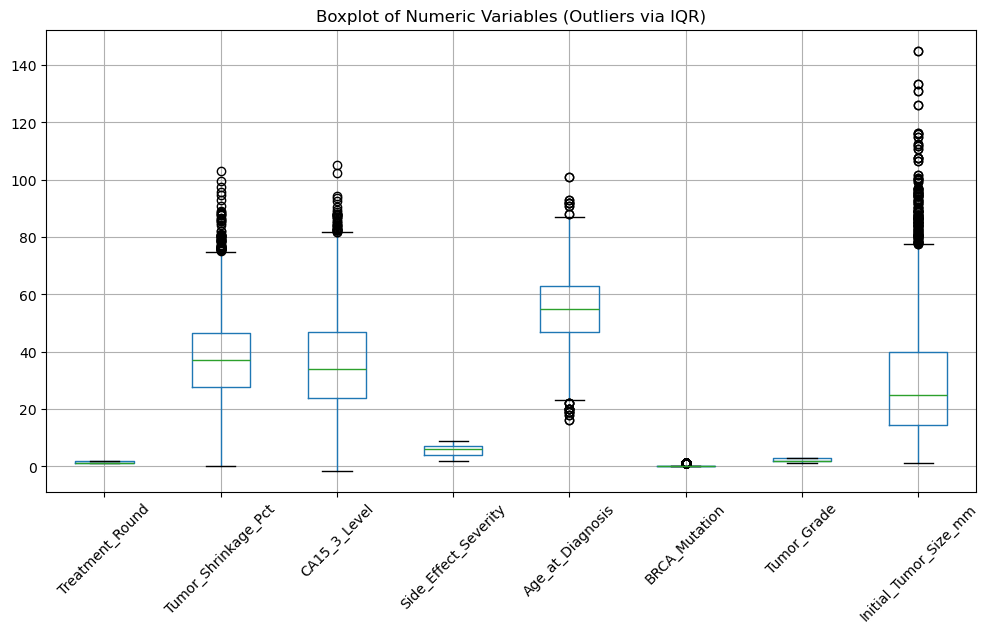

In [20]:
numeric_cols = analysis_df.select_dtypes(include=['int64', 'float64']).columns

outlier_report = detect_outliers_iqr(analysis_df, numeric_cols)

for col, info in outlier_report.items():
    print(f"\nColumn: {col}")
    print(f"Outliers: {info['outlier_count']}")
    print(info['outliers'].head())

analysis_df[numeric_cols].boxplot(figsize=(12, 6))
plt.xticks(rotation=45)
plt.title("Boxplot of Numeric Variables (Outliers via IQR)")
plt.show()

The dataset contains 4980 patient-treatment records with no missing values.


In [21]:
cleaned_df = analysis_df[
    (analysis_df['Tumor_Shrinkage_Pct'].between(0, 100)) &
    (analysis_df['Tumor_Shrinkage_Pct'].notna())
].copy()

cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4980 entries, 0 to 4980
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             4980 non-null   object 
 1   Treatment_Round        4980 non-null   int64  
 2   Regimen                4980 non-null   object 
 3   Tumor_Shrinkage_Pct    4980 non-null   float64
 4   CA15_3_Level           4980 non-null   float64
 5   Side_Effect_Severity   4980 non-null   int64  
 6   Response_Status        4980 non-null   object 
 7   Age_at_Diagnosis       4980 non-null   int64  
 8   Molecular_Subtype      4980 non-null   object 
 9   BRCA_Mutation          4980 non-null   int64  
 10  Tumor_Grade            4980 non-null   int64  
 11  Initial_Tumor_Size_mm  4980 non-null   float64
dtypes: float64(3), int64(5), object(4)
memory usage: 505.8+ KB


In [22]:
cleaned_df.describe()

,Treatment_Round,Tumor_Shrinkage_Pct,CA15_3_Level,Side_Effect_Severity,Age_at_Diagnosis,BRCA_Mutation,Tumor_Grade,Initial_Tumor_Size_mm
count,4980.000000,4980.000000,4980.000000,4980.000000,4980.000000,4980.000000,4980.000000,4980.000000
mean,1.498193,37.688739,36.450950,5.555622,54.917470,0.119880,2.096386,29.573556
std,0.500047,14.669090,16.668006,1.985264,11.793693,0.324853,0.688723,20.637408
min,1.000000,0.000000,0.260000,2.000000,16.000000,0.000000,1.000000,1.020000
25%,1.000000,27.640000,23.720000,4.000000,47.000000,0.000000,2.000000,14.450000
50%,1.000000,37.220000,33.910000,6.000000,55.000000,0.000000,2.000000,24.960000
75%,2.000000,46.527500,46.962500,7.000000,63.000000,0.000000,3.000000,39.740000
max,2.000000,99.500000,105.140000,9.000000,101.000000,1.000000,3.000000,145.110000


Most variables show weak linear relationships, suggesting that:
- non-linear models may perform better
- individual features alone may not strongly explain treatment response

A moderate relationship between CA15-3 and tumor shrinkage suggests potential clinical relevance.

In [23]:
numeric_df = cleaned_df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()
print(corr_matrix)

                       Treatment_Round  Tumor_Shrinkage_Pct  CA15_3_Level  \
Treatment_Round               1.000000            -0.508457     -0.381046   
Tumor_Shrinkage_Pct          -0.508457             1.000000     -0.226831   
CA15_3_Level                 -0.381046            -0.226831      1.000000   
Side_Effect_Severity         -0.516612             0.266197      0.195111   
Age_at_Diagnosis              0.000503             0.008619     -0.004770   
BRCA_Mutation                -0.001757            -0.012842      0.010008   
Tumor_Grade                   0.000506            -0.008512      0.026010   
Initial_Tumor_Size_mm        -0.000178            -0.020438      0.005575   

                       Side_Effect_Severity  Age_at_Diagnosis  BRCA_Mutation  \
Treatment_Round                   -0.516612          0.000503      -0.001757   
Tumor_Shrinkage_Pct                0.266197          0.008619      -0.012842   
CA15_3_Level                       0.195111         -0.004770     

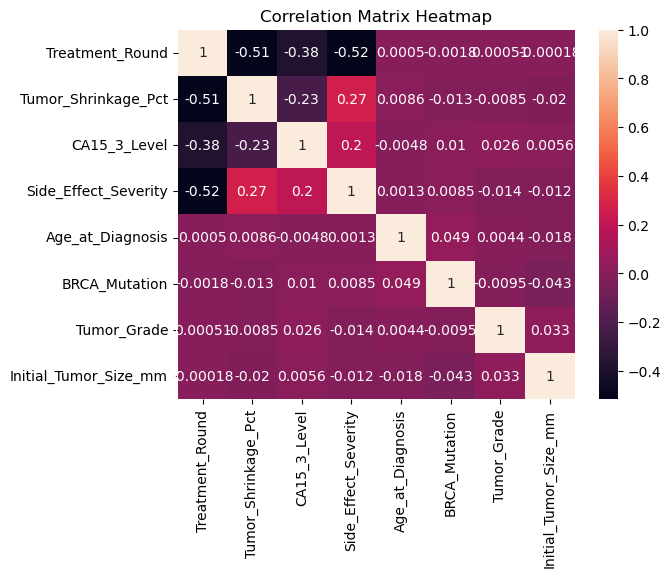

In [24]:
plt.figure()
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Matrix Heatmap")
plt.show()

The correlation analysis revealed that most variables exhibit weak linear relationships, with correlation coefficients close to zero. In particular, the relationship between CA15-3 levels and tumor shrinkage was negligible, suggesting that this biomarker alone may not be a strong predictor of treatment response in a linear context. This indicates the potential need for more complex or non-linear modeling approaches.

In [25]:
print("CA15-3 vs Tumor Shrinkage correlation:",
corr_matrix.loc['CA15_3_Level', 'Tumor_Shrinkage_Pct'])

CA15-3 vs Tumor Shrinkage correlation: -0.22683129562896434


In [29]:
analysis_df.groupby('Response_Status')[[
    'Tumor_Shrinkage_Pct',
    'CA15_3_Level',
    'Initial_Tumor_Size_mm'
]].mean()

,Tumor_Shrinkage_Pct,CA15_3_Level,Initial_Tumor_Size_mm
Response_Status,,,
Complete,90.494211,8.781053,30.040526
Partial,41.128020,34.826808,29.461122
Refractory,13.695429,38.358388,29.307000
Stable/Progressive,24.480219,59.703832,31.706131


## Key Observations

- Dataset is clean with no missing values  
- Data includes both patient-level and treatment-level features  
- Target variable is categorical (Response_Status)  
- Some invalid values were detected and removed  
- Weak correlations suggest need for advanced models  

**Описание полей датасета**

Patient_ID — Уникальный идентификатор пациента для отслеживания его данных во времени
	
Treatment_Round — Номер курса лечения (например, 1-й или 2-й цикл химиотерапии)
	
Regimen — Назначенная схема химиотерапии (комбинация препаратов)
	
Tumor_Shrinkage_Pct — Процент уменьшения опухоли по сравнению с предыдущим состоянием
	
CA15_3_Level — Уровень опухолевого маркера CA 15-3 в крови (единицы: U/mL)
	
Side_Effect_Severity — Оценка выраженности побочных эффектов по шкале от 1 до 10
	
Response_Status — Категориальная оценка эффективности лечения (например: полный ответ, частичный ответ)
	
Age_at_Diagnosis — Возраст пациента на момент постановки диагноза (в годах)
	
Molecular_Subtype — Молекулярный подтип опухоли (например: Luminal A, HER2+, Triple-negative)
	
BRCA_Mutation — Наличие мутации гена BRCA (1 — обнаружена, 0 — отсутствует)
	
Tumor_Grade — Степень злокачественности опухоли (от 1 до 3, где 3 — наиболее агрессивная)
	
Initial_Tumor_Size_mm — Исходный размер опухоли до начала лечения (в миллиметрах)